# PD1: Kidney Stone Analysis — Powder XRD + FTIR

This notebook demonstrates visualization of synthetic kidney stone composition data.
Each patient specimen produces two types of data:
- **Powder X-ray Diffraction (PXRD):** Identifies crystalline mineral phases by their diffraction pattern
- **Fourier Transform Infrared Spectroscopy (FTIR):** Identifies molecular bonds/functional groups

Together, these confirm kidney stone composition (e.g., calcium oxalate, uric acid, struvite).

**Data source:** Synthetic CIF file from `securecomputing-datagen/output/pd1_crystallography/`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

CIF_PATH = Path.home() / 'securecomputing-datagen/output/pd1_crystallography/example_stone_B48291037_001.cif'
print(f"CIF file path: {CIF_PATH}")
print(f"File exists: {CIF_PATH.exists()}")

CIF file path: /home/kilroy/securecomputing-datagen/output/pd1_crystallography/example_stone_B48291037_001.cif
File exists: True


In [2]:
def parse_cif_xrd(filepath):
    """Parse PXRD data (2theta, intensity) from a CIF file."""
    two_theta = []
    intensity = []
    in_xrd_block = False
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if '_pd_meas_2theta_scan' in line:
                in_xrd_block = True
                continue
            if '_pd_meas_intensity_total' in line:
                continue
            if in_xrd_block:
                if line.startswith('#') or line.startswith('_') or line.startswith('loop_'):
                    in_xrd_block = False
                    continue
                if line == '':
                    in_xrd_block = False
                    continue
                parts = line.split()
                if len(parts) == 2:
                    try:
                        two_theta.append(float(parts[0]))
                        intensity.append(float(parts[1]))
                    except ValueError:
                        in_xrd_block = False
    
    return np.array(two_theta), np.array(intensity)


def parse_cif_ftir(filepath):
    """Parse FTIR data (wavenumber, transmittance) from a CIF file."""
    wavenumber = []
    transmittance = []
    in_ir_block = False
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if '_pd_ir_wavenumber' in line:
                in_ir_block = True
                continue
            if '_pd_ir_transmittance' in line:
                continue
            if in_ir_block:
                if line.startswith('#') or line.startswith('_') or line.startswith('loop_'):
                    in_ir_block = False
                    continue
                if line == '':
                    in_ir_block = False
                    continue
                parts = line.split()
                if len(parts) == 2:
                    try:
                        wavenumber.append(float(parts[0]))
                        transmittance.append(float(parts[1]))
                    except ValueError:
                        in_ir_block = False
    
    return np.array(wavenumber), np.array(transmittance)


def parse_cif_metadata(filepath):
    """Extract patient and specimen metadata from CIF header."""
    metadata = {}
    with open(filepath, 'r') as f:
        for line in f:
            if 'Patient MRN:' in line:
                metadata['mrn'] = line.split('Patient MRN:')[1].strip()
            elif '_audit_creation_date' in line:
                metadata['analysis_date'] = line.split()[-1].strip("'")
            elif '_pd_phase_name' in line:
                metadata['primary_phase'] = line.split("'")[1] if "'" in line else line.split()[-1]
            elif '_pd_phase_mass_%' in line:
                metadata['primary_phase_pct'] = float(line.split()[-1])
            elif '_chemical_compound_source' in line:
                metadata['source'] = line.split("'")[1] if "'" in line else line.split()[-1]
    return metadata

In [3]:
# Parse the example CIF file
two_theta, intensity = parse_cif_xrd(CIF_PATH)
wavenumber, transmittance = parse_cif_ftir(CIF_PATH)
metadata = parse_cif_metadata(CIF_PATH)

print(f"Patient MRN: {metadata.get('mrn', 'unknown')}")
print(f"Specimen: {metadata.get('source', 'unknown')}")
print(f"Analysis date: {metadata.get('analysis_date', 'unknown')}")
print(f"Primary phase: {metadata.get('primary_phase', 'unknown')} ({metadata.get('primary_phase_pct', '?')}%)")
print(f"XRD data points: {len(two_theta)}")
print(f"FTIR data points: {len(wavenumber)}")

Patient MRN: B48291037
Specimen: Patient B48291037, left kidney
Analysis date: 2024-03-18
Primary phase: Whewellite (78.3%)
XRD data points: 20
FTIR data points: 24


Figure saved: /home/kilroy/securecomputing/analysis/notebooks/synthetic_kidney_stone_xrd_ftir.png


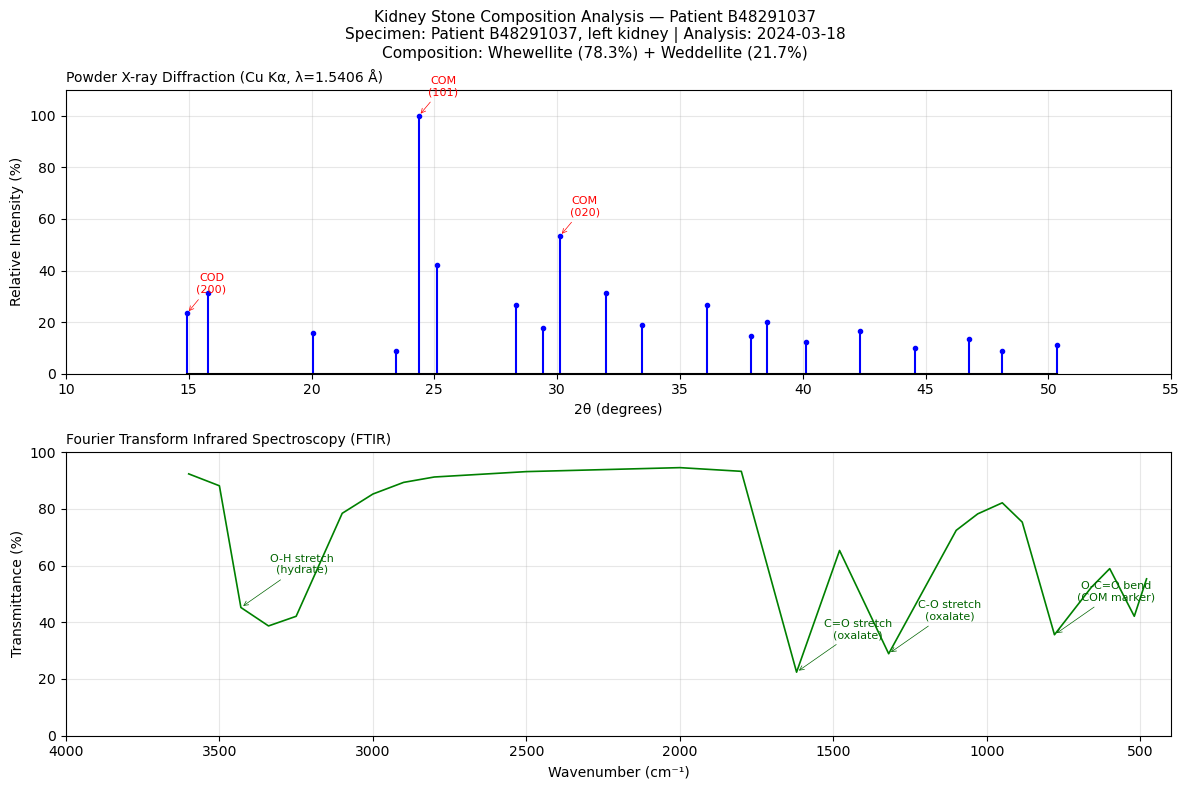

In [4]:
# Create compound chart: PXRD (top) + FTIR (bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[1, 1])
fig.suptitle(
    f"Kidney Stone Composition Analysis — Patient {metadata.get('mrn', '?')}\n"
    f"Specimen: {metadata.get('source', '?')} | Analysis: {metadata.get('analysis_date', '?')}\n"
    f"Composition: {metadata.get('primary_phase', '?')} ({metadata.get('primary_phase_pct', '?')}%) + Weddellite ({100 - metadata.get('primary_phase_pct', 0):.1f}%)",
    fontsize=11, y=0.98
)

# --- Top panel: Powder XRD ---
ax1.stem(two_theta, intensity / intensity.max() * 100, linefmt='b-', markerfmt='b.', basefmt='k-')
ax1.set_xlabel('2\u03b8 (degrees)', fontsize=10)
ax1.set_ylabel('Relative Intensity (%)', fontsize=10)
ax1.set_title('Powder X-ray Diffraction (Cu K\u03b1, \u03bb=1.5406 \u00c5)', fontsize=10, loc='left')
ax1.set_xlim(10, 55)
ax1.set_ylim(0, 110)
ax1.grid(True, alpha=0.3)

# Annotate major peaks
major_peaks = [(24.37, 'COM\n(101)'), (30.12, 'COM\n(020)'), (14.93, 'COD\n(200)')]
for peak_2theta, label in major_peaks:
    idx = np.argmin(np.abs(two_theta - peak_2theta))
    ax1.annotate(label, xy=(two_theta[idx], intensity[idx]/intensity.max()*100),
                xytext=(two_theta[idx]+1, intensity[idx]/intensity.max()*100 + 8),
                fontsize=8, color='red', ha='center',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

# --- Bottom panel: FTIR ---
ax2.plot(wavenumber, transmittance, 'g-', linewidth=1.2)
ax2.set_xlabel('Wavenumber (cm\u207b\u00b9)', fontsize=10)
ax2.set_ylabel('Transmittance (%)', fontsize=10)
ax2.set_title('Fourier Transform Infrared Spectroscopy (FTIR)', fontsize=10, loc='left')
ax2.set_xlim(4000, 400)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# Annotate characteristic FTIR peaks
ftir_peaks = [
    (3430, 'O-H stretch\n(hydrate)'),
    (1620, 'C=O stretch\n(oxalate)'),
    (1320, 'C-O stretch\n(oxalate)'),
    (780, 'O-C=O bend\n(COM marker)')
]
for wn, label in ftir_peaks:
    idx = np.argmin(np.abs(wavenumber - wn))
    ax2.annotate(label, xy=(wavenumber[idx], transmittance[idx]),
                xytext=(wavenumber[idx]-200, transmittance[idx] + 12),
                fontsize=8, color='darkgreen', ha='center',
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=0.5))

plt.tight_layout()
plt.subplots_adjust(top=0.88)

# Save figure
output_path = Path.home() / 'securecomputing/analysis/notebooks/synthetic_kidney_stone_xrd_ftir.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f'Figure saved: {output_path}')

plt.show()

## Interpretation

**PXRD (top panel):**
- Strong peak at 2\u03b8 \u2248 24.4\u00b0 corresponds to the (101) reflection of **calcium oxalate monohydrate (COM/Whewellite)** — the dominant phase
- Peak at 2\u03b8 \u2248 14.9\u00b0 corresponds to **calcium oxalate dihydrate (COD/Weddellite)** — the minor phase
- Relative peak intensities confirm ~78% COM + ~22% COD composition

**FTIR (bottom panel):**
- Broad O-H stretch at ~3430 cm\u207b\u00b9 confirms hydrated mineral
- Strong C=O stretch at ~1620 cm\u207b\u00b9 is characteristic of oxalate
- The 780 cm\u207b\u00b9 band is a specific marker for COM (distinguishes monohydrate from dihydrate)

**Clinical significance:** Calcium oxalate stones (especially COM-dominant) are the most common type.
Treatment typically includes increased fluid intake, dietary oxalate restriction, and possibly thiazide diuretics or potassium citrate.

---
*This is synthetic data generated for the securecomputing project. No real patient data is represented.*